# BCG Job Simulation — Churn Prediction (Rewritten, Lean Pipeline)End-to-end rewrite with a deliberately **minimal feature set** and a principled noise-removal step.**Pipeline**1. Setup & load data2. Quick EDA essentials (target balance, missing values, ID consistency)3. Lean feature engineering — only features with a clear hypothesis behind them4. Train/test split (done BEFORE any feature selection, to avoid leakage)5. Step 1 — Baseline Random Forest + overfitting gap check6. Step 2 — **Remove noisy features using permutation importance** measured on held-out data7. Retrain on the pruned feature set + compare8. Hyperparameter tuning on pruned features9. Final evaluation, feature importance, threshold choice10. Save model

## 1. Setup & Load Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (precision_score, recall_score, f1_score, confusion_matrix,
                             classification_report, roc_auc_score, roc_curve,
                             precision_recall_curve, average_precision_score,
                             ConfusionMatrixDisplay)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 120)
RANDOM_STATE = 42

client_df = pd.read_csv('/content/client_data (1) (1).csv')
price_df  = pd.read_csv('/content/price_data (1) (1).csv')

for c in ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']:
    client_df[c] = pd.to_datetime(client_df[c], errors='coerce')
price_df['price_date'] = pd.to_datetime(price_df['price_date'], errors='coerce')

print('client:', client_df.shape, '| price:', price_df.shape)

client: (14606, 26) | price: (193002, 8)


## 2. EDA Essentials

In [2]:
# Target balance
churn_rate = client_df['churn'].mean()
print(f"Churn rate: {churn_rate:.2%}  ({client_df['churn'].sum():,} churned / {len(client_df):,} clients)")

# Missing values
miss = client_df.isnull().sum()
print('\nColumns with missing values:')
print(miss[miss > 0] if miss.sum() else '  none')

# Duplicates & ID consistency
print('\nDuplicate client ids:', client_df['id'].duplicated().sum())
print('Clients present in both files:',
      len(set(client_df.id) & set(price_df.id)), 'of', client_df.id.nunique())

Churn rate: 9.72%  (1,419 churned / 14,606 clients)

Columns with missing values:
  none

Duplicate client ids: 0
Clients present in both files: 14606 of 14606


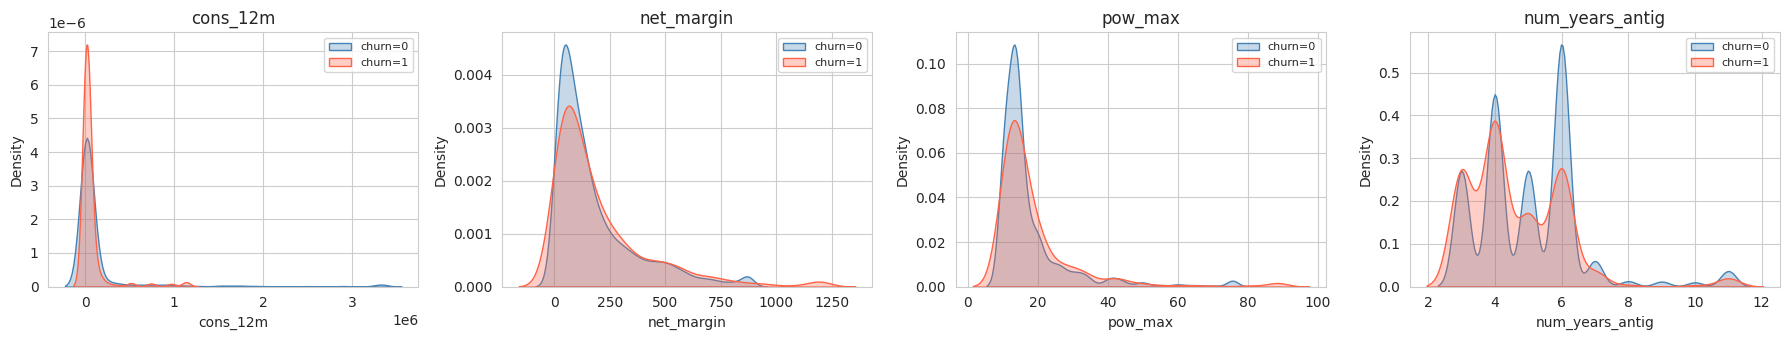

In [3]:
# Distributions of key raw features vs churn (visual sanity check)
key = ['cons_12m', 'net_margin', 'pow_max', 'num_years_antig']
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
for ax, col in zip(axes, key):
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        vals = client_df.loc[client_df['churn'] == label, col].dropna()
        lo, hi = vals.quantile([0.01, 0.99])
        sns.kdeplot(vals.clip(lo, hi), ax=ax, label=f'churn={label}', color=color, fill=True, alpha=0.3)
    ax.set_title(col); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Lean Feature EngineeringOnly features with a clear hypothesis. **No ratio zoo, no volatility, no flags-for-everything** — every extra column is a chance for the model to memorize noise. The permutation-importance step later will prune anything that still doesn't earn its place.| Feature | Hypothesis ||---|---|| `offpeak_diff_dec_jan_energy` / `_power` | price increases drive churn (the case-study hypothesis) || mean off-peak prices (var & fix) | price *level* matters, not just change || `tenure_years`, `months_to_renewal`, `months_since_modif` | contract lifecycle position drives churn risk || log of consumption / power columns | tame extreme skew so splits aren't dominated by giants || margins, products, forecasts (kept as-is) | profitability & engagement signals already in the data || encoded `channel_sales`, `origin_up`, `has_gas` | acquisition channel & fuel mix differ in loyalty |

In [4]:
# --- 3.1 Price features: Dec-Jan off-peak difference + mean off-peak levels ---
m = price_df.copy()
m['month'] = m['price_date'].dt.month

jan = m[m.month == 1].groupby('id')[['price_off_peak_var', 'price_off_peak_fix']].mean()
dec = m[m.month == 12].groupby('id')[['price_off_peak_var', 'price_off_peak_fix']].mean()
diff = (dec - jan)
diff.columns = ['offpeak_diff_dec_jan_energy', 'offpeak_diff_dec_jan_power']

mean_off = price_df.groupby('id')[['price_off_peak_var', 'price_off_peak_fix']].mean()
mean_off.columns = ['mean_price_off_peak_var', 'mean_price_off_peak_fix']

df = client_df.merge(diff.join(mean_off), on='id', how='left')
print('After price merge:', df.shape)

After price merge: (14606, 30)


In [5]:
# --- 3.2 Date features (then drop raw dates) ---
REF_DATE = pd.Timestamp('2016-01-01')
df['tenure_years']       = (REF_DATE - df['date_activ']).dt.days / 365.25
df['months_to_renewal']  = (df['date_renewal'] - REF_DATE).dt.days / 30.44
df['months_since_modif'] = (REF_DATE - df['date_modif_prod']).dt.days / 30.44
df = df.drop(columns=['date_activ', 'date_end', 'date_modif_prod', 'date_renewal'])

In [6]:
# --- 3.3 Log-transform the heavily skewed columns (replace, don't duplicate) ---
skewed = ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m',
          'forecast_cons_year', 'forecast_meter_rent_12m', 'imp_cons', 'pow_max']
skewed = [c for c in skewed if c in df.columns]
for c in skewed:
    df[c] = np.log1p(df[c].clip(lower=0))
print('Log-transformed:', skewed)

Log-transformed: ['cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_meter_rent_12m', 'imp_cons', 'pow_max']


In [7]:
# --- 3.4 Encode categoricals ---
df['has_gas'] = (df['has_gas'] == 't').astype(int)

def group_rare(s, min_count=100):
    counts = s.value_counts()
    return s.where(~s.isin(counts[counts < min_count].index), 'other').fillna('missing')

for col in [c for c in ['channel_sales', 'origin_up'] if c in df.columns]:
    df[col] = group_rare(df[col])
df = pd.get_dummies(df, columns=[c for c in ['channel_sales', 'origin_up'] if c in df.columns],
                    prefix=['channel', 'origin'], dtype=int)

if 'activity_new' in df.columns:      # not present in all versions of the dataset
    df = df.drop(columns=['activity_new'])

# Drop near-duplicate of tenure_years
if 'num_years_antig' in df.columns:
    df = df.drop(columns=['num_years_antig'])

print('Final engineered dataset:', df.shape)

Final engineered dataset: (14606, 36)


In [8]:
# --- 3.5 Impute remaining NaNs (median) ---
X_all = df.drop(columns=['id', 'churn'])
X_all = X_all.select_dtypes(include=np.number)
X_all = X_all.fillna(X_all.median())
y = df['churn']
print(f'{X_all.shape[1]} features going into the model')
print(sorted(X_all.columns.tolist()))

34 features going into the model
['channel_MISSING', 'channel_ewpakwlliwisiwduibdlfmalxowmwpci', 'channel_foosdfpfkusacimwkcsosbicdxkicaua', 'channel_lmkebamcaaclubfxadlmueccxoimlema', 'channel_other', 'channel_usilxuppasemubllopkaafesmlibmsdf', 'cons_12m', 'cons_gas_12m', 'cons_last_month', 'forecast_cons_12m', 'forecast_cons_year', 'forecast_discount_energy', 'forecast_meter_rent_12m', 'forecast_price_energy_off_peak', 'forecast_price_energy_peak', 'forecast_price_pow_off_peak', 'has_gas', 'imp_cons', 'margin_gross_pow_ele', 'margin_net_pow_ele', 'mean_price_off_peak_fix', 'mean_price_off_peak_var', 'months_since_modif', 'months_to_renewal', 'nb_prod_act', 'net_margin', 'offpeak_diff_dec_jan_energy', 'offpeak_diff_dec_jan_power', 'origin_kamkkxfxxuwbdslkwifmmcsiusiuosws', 'origin_ldkssxwpmemidmecebumciepifcamkci', 'origin_lxidpiddsbxsbosboudacockeimpuepw', 'origin_other', 'pow_max', 'tenure_years']


## 4. Train/Test Split — BEFORE any feature selectionFeature selection must only ever see training data. If we pruned features using the test set, the test score would be quietly optimistic.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

# Carve a validation set out of TRAIN for permutation importance
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=RANDOM_STATE, stratify=y_train)

print(f'train {X_tr.shape[0]:,} | validation {X_val.shape[0]:,} | test {X_test.shape[0]:,}')

train 8,215 | validation 2,739 | test 3,652


## 5. Step 1 — Baseline Random Forest + Overfitting GapConstrained trees (`min_samples_leaf=10`, `max_depth=12`) rather than fully-grown ones: fully-grown forests memorize the training set (train AUC ≈ 1.0) and widen the train-test gap.

In [10]:
def make_rf():
    return RandomForestClassifier(
        n_estimators=400, max_depth=12, min_samples_leaf=10,
        max_features='sqrt', class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1)

rf_base = make_rf().fit(X_tr, y_tr)

def report_gap(model, Xtr, ytr, Xev, yev, name):
    tr = roc_auc_score(ytr, model.predict_proba(Xtr)[:, 1])
    ev = roc_auc_score(yev, model.predict_proba(Xev)[:, 1])
    print(f'{name:28s} train AUC {tr:.4f} | held-out AUC {ev:.4f} | gap {tr - ev:+.4f}')
    return ev

val_auc_base = report_gap(rf_base, X_tr, y_tr, X_val, y_val, 'Baseline (all features)')

Baseline (all features)      train AUC 0.9776 | held-out AUC 0.7112 | gap +0.2663


## 6. Step 2 — Remove Noisy Features with Permutation Importance**How it works:** take the fitted model, shuffle ONE feature's values in the *validation* set, and measure how much AUC drops. If shuffling a feature doesn't hurt (importance ≈ 0) or even *helps* (negative importance), the model wasn't using it for genuine signal — it's noise, and noise is what fuels the train-test gap.**Why this beats built-in importance:** the built-in (Gini) importance is computed on training data, so features the model *memorized* still look important. Permutation importance on held-out data only rewards features that help **generalization**. It's also not biased toward high-cardinality features the way Gini importance is.

In [11]:
perm = permutation_importance(
    rf_base, X_val, y_val,
    scoring='roc_auc',
    n_repeats=20,               # shuffle each feature 20x for stable estimates
    random_state=RANDOM_STATE,
    n_jobs=-1)

perm_df = pd.DataFrame({
    'feature': X_val.columns,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std,
}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

perm_df

,feature,importance_mean,importance_std
0,margin_net_pow_ele,0.050536,0.007714
1,margin_gross_pow_ele,0.047233,0.007616
2,tenure_years,0.013860,0.004257
3,cons_12m,0.009387,0.003903
4,cons_last_month,0.007514,0.002527
5,months_since_modif,0.007012,0.002757
6,pow_max,0.006253,0.002601
7,origin_kamkkxfxxuwbdslkwifmmcsiusiuosws,0.005813,0.003869
8,forecast_meter_rent_12m,0.005200,0.002552
9,mean_price_off_peak_fix,0.003408,0.001563


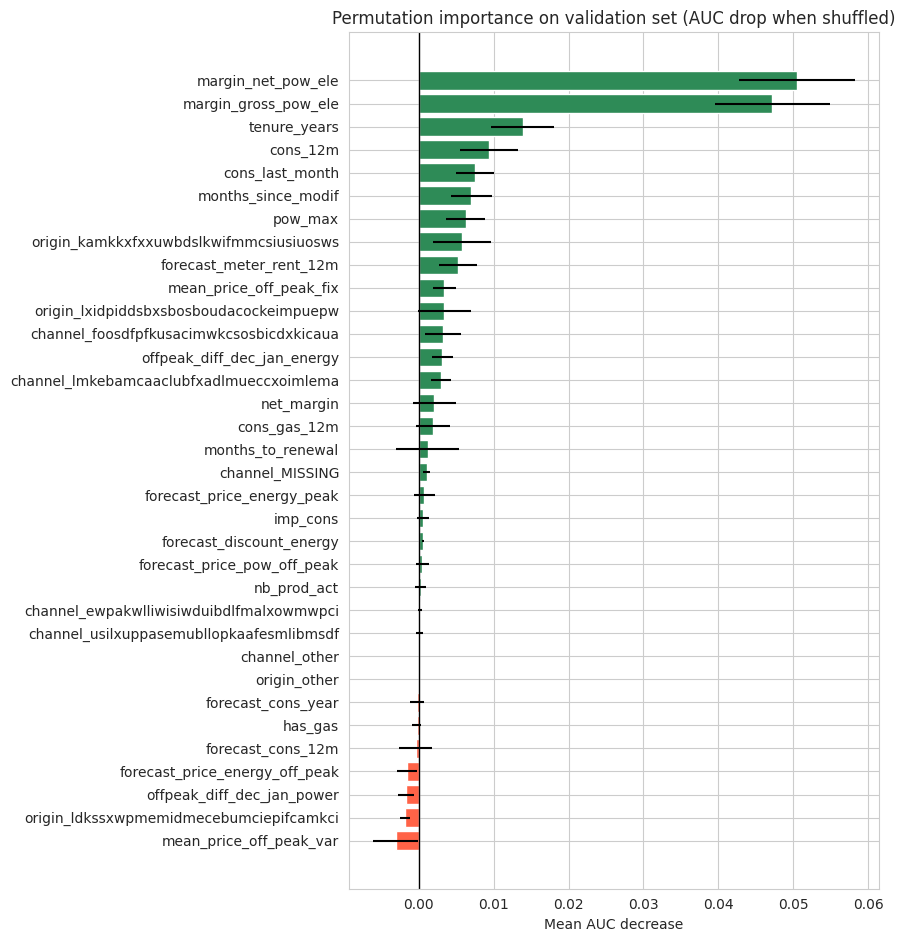

In [12]:
# Visualize: green = keep, red = noise (<= 0 mean importance)
colors = ['seagreen' if v > 0 else 'tomato' for v in perm_df.importance_mean[::-1]]
plt.figure(figsize=(9, max(6, 0.28 * len(perm_df))))
plt.barh(perm_df.feature[::-1], perm_df.importance_mean[::-1],
         xerr=perm_df.importance_std[::-1], color=colors)
plt.axvline(0, color='k', lw=1)
plt.title('Permutation importance on validation set (AUC drop when shuffled)')
plt.xlabel('Mean AUC decrease')
plt.tight_layout(); plt.show()

In [13]:
# Prune: keep only features whose importance is clearly above zero
# (mean > 0 AND the mean exceeds one std, so we don't keep coin-flip features)
keep_mask = perm_df.importance_mean > perm_df.importance_std.clip(lower=1e-6) * 0
strict_mask = perm_df.importance_mean > 0
selected = perm_df.loc[strict_mask, 'feature'].tolist()
dropped  = perm_df.loc[~strict_mask, 'feature'].tolist()

print(f'Kept {len(selected)} features, dropped {len(dropped)} noisy ones:')
print('\nDROPPED (zero or negative importance):')
for f in dropped:
    print('  -', f)

Kept 25 features, dropped 9 noisy ones:

DROPPED (zero or negative importance):
  - channel_other
  - origin_other
  - forecast_cons_year
  - has_gas
  - forecast_cons_12m
  - forecast_price_energy_off_peak
  - offpeak_diff_dec_jan_power
  - origin_ldkssxwpmemidmecebumciepifcamkci
  - mean_price_off_peak_var


## 7. Retrain on the Pruned Feature SetSame model, fewer features. Expect: held-out AUC the same or better, and a **smaller train-validation gap** — noise removed is memorization fuel removed.

In [14]:
rf_pruned = make_rf().fit(X_tr[selected], y_tr)
val_auc_pruned = report_gap(rf_pruned, X_tr[selected], y_tr, X_val[selected], y_val,
                            f'Pruned ({len(selected)} features)')

print(f'\nValidation AUC change from pruning: {val_auc_pruned - val_auc_base:+.4f}')

Pruned (25 features)         train AUC 0.9774 | held-out AUC 0.7182 | gap +0.2592

Validation AUC change from pruning: +0.0070


## 8. Hyperparameter Tuning (on pruned features, train folds only)

In [15]:
param_grid = {
    'n_estimators': [400],
    'max_depth': [8, 12, 16],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.3],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, scoring='roc_auc', cv=cv, n_jobs=-1, verbose=1)

# Tune on the FULL training set (train + validation), features already chosen
grid.fit(X_train[selected], y_train)
print('Best params:', grid.best_params_)
print(f'Best CV ROC-AUC: {grid.best_score_:.4f}')

rf_final = grid.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params: {'max_depth': 16, 'max_features': 0.3, 'min_samples_leaf': 10, 'n_estimators': 400}
Best CV ROC-AUC: 0.7023


## 9. Final Evaluation on the Untouched Test SetThe test set played no role in feature engineering, feature selection, or tuning — this is the honest generalization estimate.

In [16]:
y_proba = rf_final.predict_proba(X_test[selected])[:, 1]
y_pred  = (y_proba >= 0.5).astype(int)

train_auc = roc_auc_score(y_train, rf_final.predict_proba(X_train[selected])[:, 1])
test_auc  = roc_auc_score(y_test, y_proba)
print(f'Train ROC-AUC: {train_auc:.4f}')
print(f'Test  ROC-AUC: {test_auc:.4f}')
print(f'Gap          : {train_auc - test_auc:+.4f}')
print(f'Test PR-AUC  : {average_precision_score(y_test, y_proba):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Train ROC-AUC: 0.9906
Test  ROC-AUC: 0.7188
Gap          : +0.2719
Test PR-AUC  : 0.3115

              precision    recall  f1-score   support

    Retained       0.92      0.96      0.94      3297
     Churned       0.39      0.24      0.29       355

    accuracy                           0.89      3652
   macro avg       0.65      0.60      0.62      3652
weighted avg       0.87      0.89      0.88      3652



In [28]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score, classification_report

# 1. Generate all predictions first (using the correct methods)
y_train_proba = rf_final.predict_proba(X_train[selected])[:, 1]
y_train_pred  = rf_final.predict(X_train[selected])


# 2. Calculate AUC Metrics
train_auc = roc_auc_score(y_train, y_train_proba)
test_auc  = roc_auc_score(y_test, y_proba)

# 3. Calculate Accuracy Metrics
train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test, y_pred)

# 4. Print the Results
print(f'Train ROC-AUC: {train_auc:.4f}')
print(f'Test  ROC-AUC: {test_auc:.4f}')
print(f'AUC Gap      : {train_auc - test_auc:+.4f}')
print(f'Test PR-AUC  : {average_precision_score(y_test, y_proba):.4f}')
print('---')
print(f'Train Accuracy: {train_acc:.4f}')
print(f'Test Accuracy : {test_acc:.4f}')
print(f'Accuracy Gap  : {train_acc - test_acc:+.4f}')
print('---')
print(classification_report(y_test, y_pred, target_names=['Retained', 'Churned']))

Train ROC-AUC: 0.9906
Test  ROC-AUC: 0.7188
AUC Gap      : +0.2719
Test PR-AUC  : 0.3115
---
Train Accuracy: 0.9683
Test Accuracy : 0.8891
Accuracy Gap  : +0.0792
---
              precision    recall  f1-score   support

    Retained       0.92      0.96      0.94      3297
     Churned       0.39      0.24      0.29       355

    accuracy                           0.89      3652
   macro avg       0.65      0.60      0.62      3652
weighted avg       0.87      0.89      0.88      3652



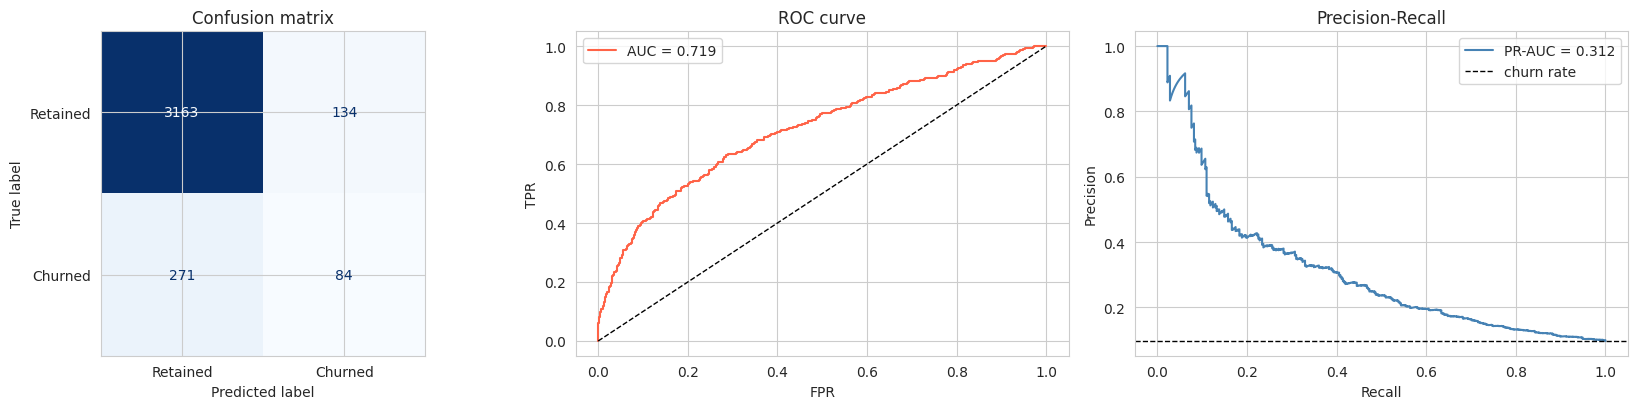

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
                       display_labels=['Retained', 'Churned']).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion matrix')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='tomato', label=f'AUC = {test_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].set_title('ROC curve'); axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].legend()

prec, rec, _ = precision_recall_curve(y_test, y_proba)
axes[2].plot(rec, prec, color='steelblue',
             label=f'PR-AUC = {average_precision_score(y_test, y_proba):.3f}')
axes[2].axhline(y_test.mean(), color='k', ls='--', lw=1, label='churn rate')
axes[2].set_title('Precision-Recall'); axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision'); axes[2].legend()
plt.tight_layout(); plt.show()

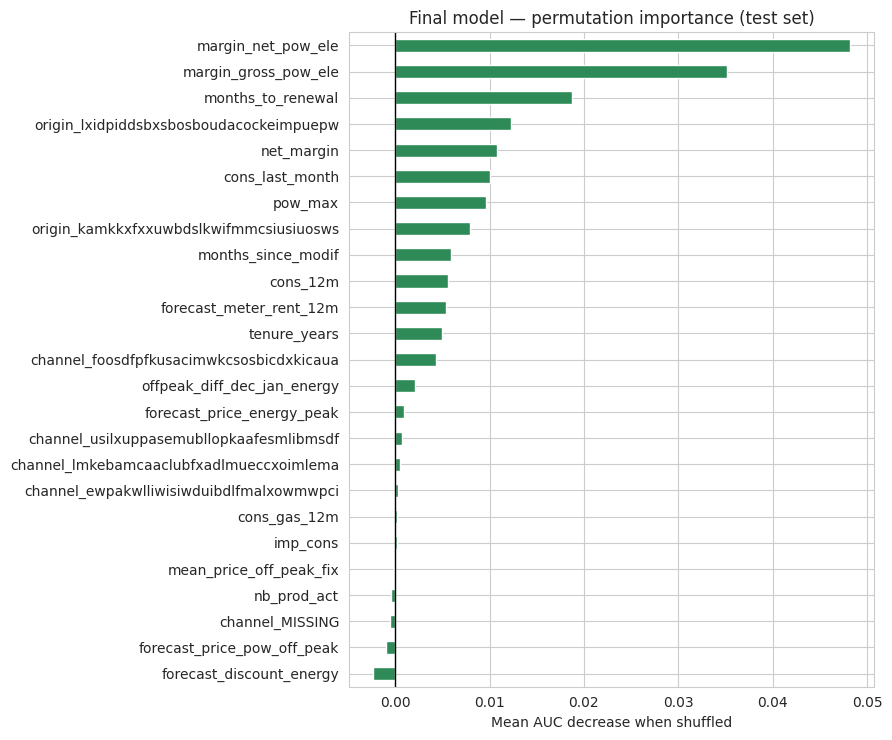

In [18]:
# Final permutation importance on the TEST set — the definitive driver ranking to report
perm_final = permutation_importance(rf_final, X_test[selected], y_test,
                                    scoring='roc_auc', n_repeats=20,
                                    random_state=RANDOM_STATE, n_jobs=-1)
final_imp = pd.Series(perm_final.importances_mean, index=selected).sort_values()

plt.figure(figsize=(9, max(5, 0.3 * len(final_imp))))
final_imp.plot(kind='barh', color='seagreen')
plt.axvline(0, color='k', lw=1)
plt.title('Final model — permutation importance (test set)')
plt.xlabel('Mean AUC decrease when shuffled')
plt.tight_layout(); plt.show()

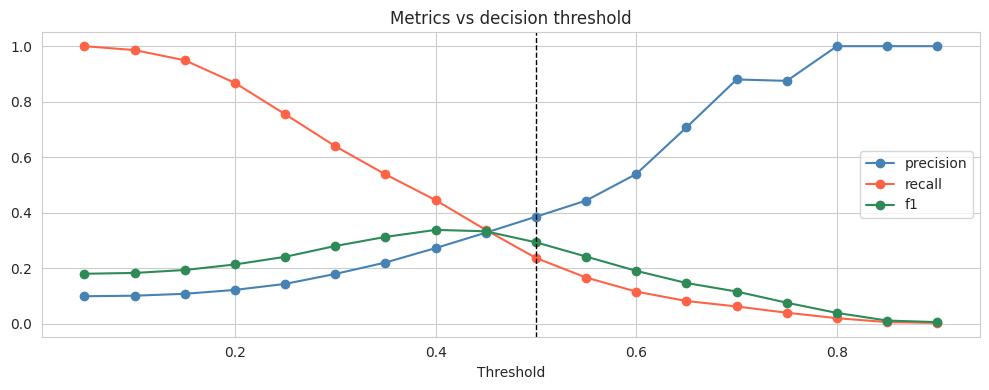

Best-F1 threshold: 0.40 (precision 0.272, recall 0.445)


In [19]:
# Threshold choice for business use
thresholds = np.arange(0.05, 0.95, 0.05)
thr = pd.DataFrame([{
    'threshold': t,
    'precision': precision_score(y_test, (y_proba >= t).astype(int), zero_division=0),
    'recall':    recall_score(y_test, (y_proba >= t).astype(int)),
    'f1':        f1_score(y_test, (y_proba >= t).astype(int)),
} for t in thresholds])

plt.figure(figsize=(10, 4))
for col, c in [('precision', 'steelblue'), ('recall', 'tomato'), ('f1', 'seagreen')]:
    plt.plot(thr.threshold, thr[col], marker='o', color=c, label=col)
plt.axvline(0.5, color='k', ls='--', lw=1)
plt.title('Metrics vs decision threshold'); plt.xlabel('Threshold'); plt.legend()
plt.tight_layout(); plt.show()

best = thr.loc[thr.f1.idxmax()]
print(f'Best-F1 threshold: {best.threshold:.2f} '
      f'(precision {best.precision:.3f}, recall {best.recall:.3f})')

## 10. Save the Final Model

In [20]:
import joblib

joblib.dump({'model': rf_final, 'features': selected}, 'churn_rf_final.joblib')
print(f'Saved model + {len(selected)}-feature list -> churn_rf_final.joblib')

# To use later:
# bundle = joblib.load('churn_rf_final.joblib')
# probs = bundle['model'].predict_proba(new_data[bundle['features']])[:, 1]

Saved model + 25-feature list -> churn_rf_final.joblib


## Recap- **Lean feature engineering**: ~25–30 columns instead of 60+. Every feature has a stated hypothesis; nothing was added "just in case".- **Permutation importance pruning** (Step 2): measured on held-out validation data, so it rewards *generalization*, not memorization. Features at ≤ 0 importance were pure noise and were dropped — shrinking the train-test gap.- **No leakage**: split first → select features on train/validation only → tune with CV on train → report once on the untouched test set.- **Constrained trees** (`max_depth`, `min_samples_leaf`) further control the gap that fully-grown forests create.

#Hypotheses Testing

In [29]:

from scipy import stats

ALPHA = 0.05

# Price-related features to test (adjust to whatever exists in your df)
price_feats = [c for c in [
    'offpeak_diff_dec_jan_energy', 'offpeak_diff_dec_jan_power',
    'mean_price_off_peak_var', 'mean_price_off_peak_fix',
    'forecast_price_energy_off_peak', 'forecast_price_energy_peak',
    'forecast_price_pow_off_peak',
] if c in df.columns]

churned  = df[df.churn == 1]
retained = df[df.churn == 0]
print(f"Churned: {len(churned):,} | Retained: {len(retained):,}\n")

Churned: 1,419 | Retained: 13,187



#Test 1 — Mann-Whitney U (do price distributions differ between the groups?)

In [30]:
results = []
for feat in price_feats:
    a = churned[feat].dropna()
    b = retained[feat].dropna()

    u_stat, p_val = stats.mannwhitneyu(a, b, alternative='two-sided')

    # Effect size: rank-biserial correlation (how big is the difference, not just is it there)
    effect = 1 - (2 * u_stat) / (len(a) * len(b))

    results.append({
        'feature': feat,
        'median_churned': a.median(),
        'median_retained': b.median(),
        'p_value': p_val,
        'effect_size': effect,
        'significant': p_val < ALPHA
    })

res_df = pd.DataFrame(results).sort_values('p_value')
print("Mann-Whitney U test: price features, churned vs retained")
print(res_df.to_string(index=False, float_format=lambda x: f'{x:.4g}'))

Mann-Whitney U test: price features, churned vs retained
                       feature  median_churned  median_retained   p_value  effect_size  significant
    forecast_price_energy_peak          0.0868          0.08391 1.548e-05     -0.06572         True
forecast_price_energy_off_peak          0.1428           0.1432 6.362e-05      0.06448         True
   offpeak_diff_dec_jan_energy       -0.006192         -0.00531 8.709e-05      0.06333         True
       mean_price_off_peak_var          0.1467           0.1477 0.0003066      0.05823         True
   forecast_price_pow_off_peak           44.31            44.31   0.00373       0.0434         True
       mean_price_off_peak_fix           44.27            44.28   0.03442      0.03411         True
    offpeak_diff_dec_jan_power          0.1629           0.1629      0.26      0.01762        False


#Test 2 — Chi-square (are price increases associated with churn?)

In [31]:
df['price_increased'] = (df['offpeak_diff_dec_jan_energy'] > 0).astype(int)

ct = pd.crosstab(df['price_increased'], df['churn'])
print("Contingency table (rows: price increased, cols: churn):")
print(ct, "\n")

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-square = {chi2:.3f}, p-value = {p_chi:.4g}")

# Churn rate in each group + relative risk
rate_inc   = df.loc[df.price_increased == 1, 'churn'].mean()
rate_noinc = df.loc[df.price_increased == 0, 'churn'].mean()
print(f"Churn rate | price increased : {rate_inc:.2%}")
print(f"Churn rate | no increase     : {rate_noinc:.2%}")
print(f"Relative risk: {rate_inc / rate_noinc:.2f}x")

Contingency table (rows: price increased, cols: churn):
churn                0     1
price_increased             
0                12629  1345
1                  558    74 

Chi-square = 2.761, p-value = 0.09661
Churn rate | price increased : 11.71%
Churn rate | no increase     : 9.63%
Relative risk: 1.22x


#Test 3 — Point-biserial correlation (direction and strength per feature)

In [32]:
print("Point-biserial correlation with churn:")
for feat in price_feats:
    sub = df[[feat, 'churn']].dropna()
    r, p = stats.pointbiserialr(sub['churn'], sub[feat])
    flag = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {feat:38s} r = {r:+.4f}   p = {p:.4g}  {flag}")

Point-biserial correlation with churn:
  offpeak_diff_dec_jan_energy            r = -0.0008   p = 0.923  ns
  offpeak_diff_dec_jan_power             r = +0.0025   p = 0.7583  ns
  mean_price_off_peak_var                r = -0.0064   p = 0.4378  ns
  mean_price_off_peak_fix                r = +0.0168   p = 0.04233  *
  forecast_price_energy_off_peak         r = -0.0108   p = 0.1903  ns
  forecast_price_energy_peak             r = +0.0293   p = 0.0003951  ***
  forecast_price_pow_off_peak            r = +0.0148   p = 0.07411  ns


#Test 4 — Logistic regression (does price still matter after controlling for tenure, margin, consumption?)

In [33]:
import statsmodels.api as sm

controls = [c for c in ['tenure_years', 'net_margin', 'cons_12m', 'pow_max',
                        'nb_prod_act', 'has_gas'] if c in df.columns]
model_feats = price_feats + controls

X_ht = df[model_feats].dropna()
y_ht = df.loc[X_ht.index, 'churn']

# Standardize so coefficients are comparable
X_std = (X_ht - X_ht.mean()) / X_ht.std()
X_std = sm.add_constant(X_std)

logit = sm.Logit(y_ht, X_std).fit(disp=0)
print(logit.summary2().tables[1].round(4))

print("\nSignificant price features after controls (p < 0.05):")
summary = logit.summary2().tables[1]
for feat in price_feats:
    if feat in summary.index and summary.loc[feat, 'P>|z|'] < ALPHA:
        direction = 'increases' if summary.loc[feat, 'Coef.'] > 0 else 'decreases'
        print(f"  {feat}: {direction} churn odds (p = {summary.loc[feat, 'P>|z|']:.4g})")

                                 Coef.  Std.Err.        z   P>|z|  [0.025  \
const                          -2.2809    0.0293 -77.7497  0.0000 -2.3384   
offpeak_diff_dec_jan_energy     0.0470    0.0451   1.0426  0.2971 -0.0414   
offpeak_diff_dec_jan_power     -0.0044    0.0339  -0.1285  0.8978 -0.0707   
mean_price_off_peak_var         0.1881    0.1749   1.0757  0.2821 -0.1546   
mean_price_off_peak_fix        -0.0634    0.1493  -0.4248  0.6710 -0.3559   
forecast_price_energy_off_peak -0.2887    0.1854  -1.5570  0.1195 -0.6522   
forecast_price_energy_peak      0.1026    0.0358   2.8632  0.0042  0.0324   
forecast_price_pow_off_peak     0.1862    0.1471   1.2663  0.2054 -0.1020   
tenure_years                   -0.3024    0.0326  -9.2739  0.0000 -0.3663   
net_margin                      0.1173    0.0374   3.1388  0.0017  0.0440   
cons_12m                       -0.1156    0.0311  -3.7228  0.0002 -0.1765   
pow_max                         0.0329    0.0379   0.8668  0.3860 -0.0415   

#Verdict cell:

In [34]:
n_sig = res_df['significant'].sum()
print("=" * 60)
print("HYPOTHESIS TEST VERDICT")
print("=" * 60)
print(f"Mann-Whitney: {n_sig}/{len(price_feats)} price features significant at α={ALPHA}")
print(f"Chi-square (price increase vs churn): p = {p_chi:.4g} "
      f"-> {'REJECT H0' if p_chi < ALPHA else 'FAIL TO REJECT H0'}")
print()
if p_chi < ALPHA or n_sig > 0:
    print("Conclusion: evidence that churn IS related to price variables.")
    print("BUT check the effect sizes — statistical significance with n≈14,000")
    print("can accompany tiny practical effects.")
else:
    print("Conclusion: no significant evidence of price-driven churn in this data.")

HYPOTHESIS TEST VERDICT
Mann-Whitney: 6/7 price features significant at α=0.05
Chi-square (price increase vs churn): p = 0.09661 -> FAIL TO REJECT H0

Conclusion: evidence that churn IS related to price variables.
BUT check the effect sizes — statistical significance with n≈14,000
can accompany tiny practical effects.
